2. Случайная величина имеет экспоненциальный закон распределения

$$
p(x) =
\begin{cases} 
e^{-x}, & x \geq 0, \\
0, & x < 0.
\end{cases}
$$

Сгенерируйте выборку объема \( n = 25 \).

a) Определить по выборке моду, медиану, размах, оценку коэффициента асимметрии.

b) Построить эмпирическую функцию распределения, гистограмму и boxplot.

c) Сравнить оценку плотности распределения среднего арифметического элементов выборки, полученную с помощью ЦПТ, с бутстраповской оценкой этой плотности.

d) Найти бутстраповскую оценку плотности распределения коэффициента асимметрии и оценить вероятность того, что коэффициент асимметрии будет меньше 1.

e) Сравнить плотность распределения медианы выборки с бутстраповской оценкой этой плотности.

In [112]:
#подключение всех необходимых библиотек

import numpy as np
import matplotlib.pyplot as plt
import collections
from scipy import stats

In [113]:
#Генерация выборки

def generate_sample():
    y = np.random.random()
    x = -np.log(1-y)
    return x

sample = [0]*25
for i in range(25):
    sample[i] = generate_sample()
sample = np.array(sample)

In [114]:
#Пункт а)

def find_moda(sample):
    vals, counts = np.unique(sample, return_counts=True)
    max_counts = np.max(counts)
    modas = vals[counts==max_counts]
    if max_counts==1:
        print("Моды нет (все числа встречаются по одному разу)")
    elif len(modas)>1:
        print(f"Мод несколько: {modas}")
    else:
        print(f"Мода выборки: {modas[0]}")
    return modas

mods_sample = find_moda(sample)

def find_ms_median(sample):
    print(f"\nМедиана выборки: {np.median(sample)}")
    return np.median(sample)

median_sample = find_ms_median(sample)

def find_razmax(sample):
    l = np.max(sample) - np.min(sample)
    print(f"\nРазмах выборки: {l}")
    return l

l_sample = find_razmax(sample)

def asymmetry_coefficient(sample):
    A = stats.skew(sample, bias=False)
    print(f"\nОценка коэффициента асимметрии (коэффициент асимметрии выборки): {A}")
    return A

a = asymmetry_coefficient(sample)


Моды нет (все числа встречаются по одному разу)

Медиана выборки: 0.7107173623022223

Размах выборки: 3.1450152037724495

Оценка коэффициента асимметрии (коэффициент асимметрии выборки): 1.3035580412503214


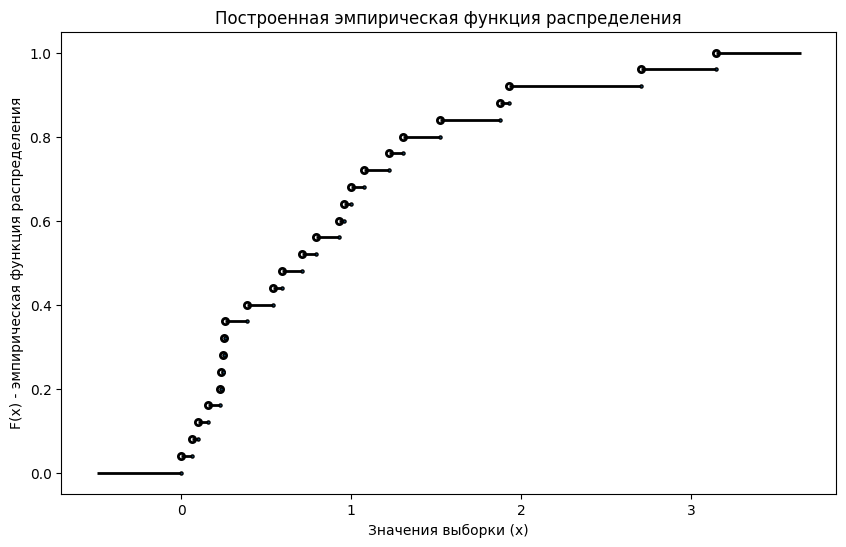

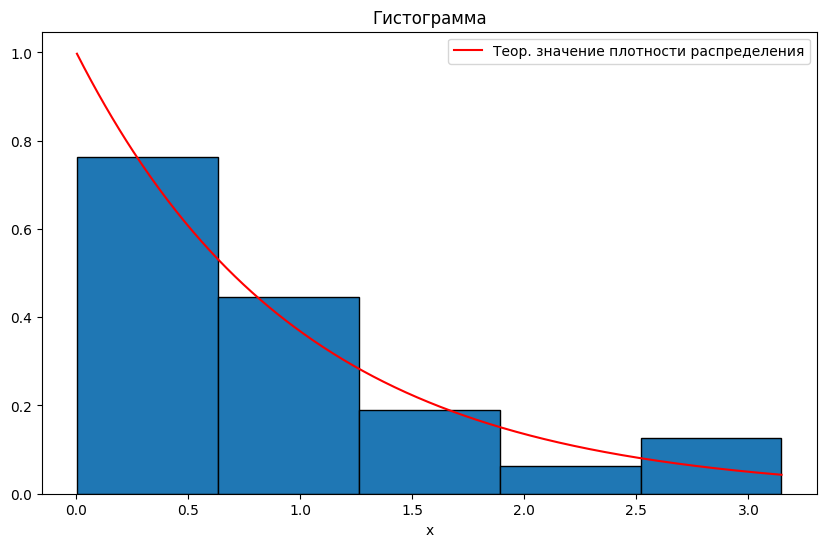

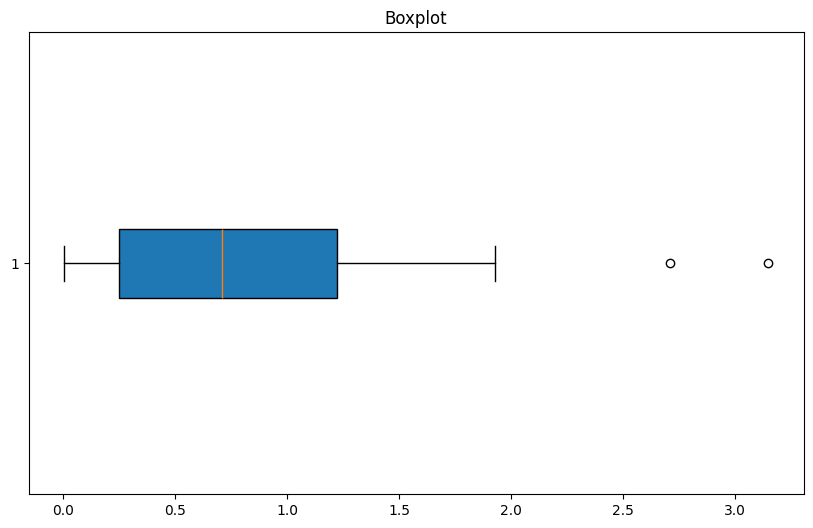

In [115]:
#Пункт b)

def build_empir_func(sample):
    X= np.sort(sample)
    Y = np.arange(1, len(X) + 1) / len(X) - 1.0/25

    plt.figure(figsize=(10, 6))
    plt.scatter(
        X, Y + 1.0/25,
        edgecolors="black",
        facecolors="white",
        s=20,
        alpha=1,
        linewidth=2)

    for i in range(len(X)):
        if i==0:
            plt.hlines(
                y=0,
                xmin=X[i]-0.5,
                xmax=X[i],
                colors='black',
                linewidth=2
            )
        else:
            plt.hlines(
                y=Y[i],
                xmin=X[i-1],
                xmax=X[i],
                colors='black',
                linewidth=2
            )
    plt.hlines(
                y=1,
                xmin=X[-1],
                xmax=X[-1]+0.5,
                colors='black',
                linewidth=2
            )
    plt.xlabel("Значения выборки (x)")
    plt.ylabel("F(x) - эмпирическая функция распределения")
    plt.title("Построенная эмпирическая функция распределения")
    # plt.xticks(X)
    plt.scatter(
        X, Y,
        edgecolors="black",
        s=5,
        alpha=1,)
    
    plt.show()

build_empir_func(sample)

def plot_hyst(sample):
    k = 1 + int(np.log2(len(sample)))
    plt.figure(figsize=(10, 6))
    plt.hist(np.sort(sample), k, density=True, edgecolor="black")
    plt.title("Гистограмма")
    plt.xlabel("x")

    x_th = np.linspace(np.min(sample), np.max(sample), 500)
    y_th = stats.expon.pdf(x_th, scale=1)

    plt.plot(x_th, y_th, c="red", label="Теор. значение плотности распределения")
    plt.legend(loc='upper right')

    plt.show()

plot_hyst(sample)

def build_boxplot(sample):
    plt.figure(figsize=(10,6))
    plt.boxplot(sample, vert=False, patch_artist=True)
    plt.title("Boxplot")

    
    plt.show()

build_boxplot(sample)


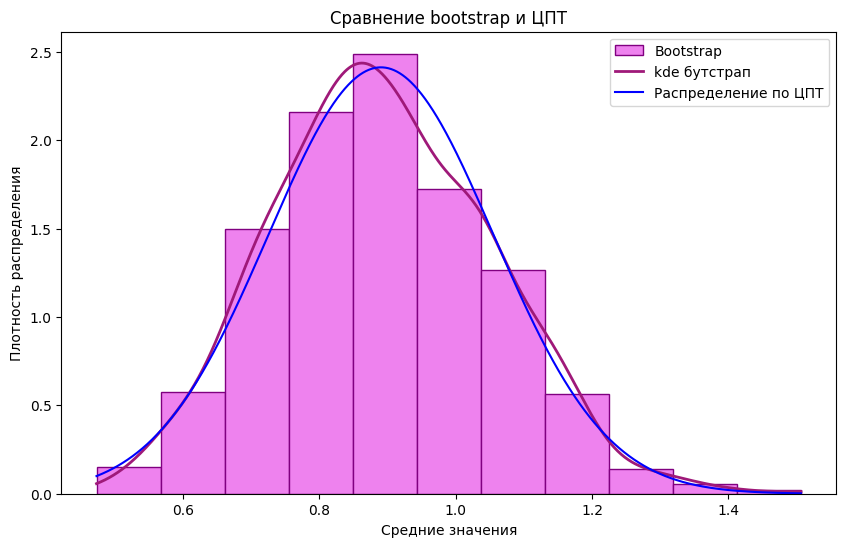

In [116]:
#Пункт с)

def bootstrap_samples_generate(sample):
    n = len(sample)
    n_bootstrap = 1000
    indices = np.random.choice(n, size=(n_bootstrap, n), replace=True)
    bootstrap_samples = sample[indices]
    return bootstrap_samples

bsp_samples = bootstrap_samples_generate(sample)
bootstrap_ocenkas = np.mean(bsp_samples, axis=1)

mean_sample = np.mean(sample)
std_sample = np.std(sample, ddof=1)
std_error = std_sample / np.sqrt(len(sample))

x = np.linspace(min(bootstrap_ocenkas), max(bootstrap_ocenkas), 1000)
y_cpt = stats.norm.pdf(x, mean_sample, std_error)

k_bs = 1 + int(np.round(np.log2(1000)))
plt.figure(figsize=(10, 6))
plt.hist(np.sort(bootstrap_ocenkas), k_bs, density=True, edgecolor="purple", facecolor="violet", label="Bootstrap")
plt.title("Сравнение bootstrap и ЦПТ")
plt.ylabel("Плотность распределения")
plt.xlabel("Средние значения")
kde = stats.gaussian_kde(bootstrap_ocenkas)
x = np.linspace(np.min(bootstrap_ocenkas), np.max(bootstrap_ocenkas), 1000)
y_kde = kde(x)
plt.plot(x, y_kde, linewidth=2, label='kde бутстрап', color="#9F1979FF")
plt.plot(x, y_cpt, c="blue", label="Распределение по ЦПТ")
plt.legend(loc="upper right")
plt.show()

Вероятность иметь коэф. асимметрии меньше 1: 0.401


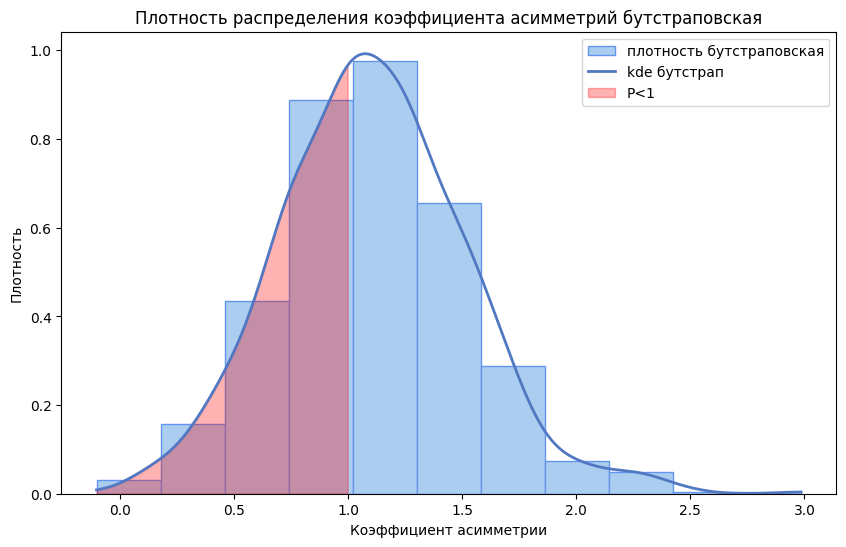

In [117]:
#Пункт d)

bsp_skews = np.array([stats.skew(i) for i in bsp_samples])

k_bs_sk = 1 + int(np.round(np.log2(1000)))
plt.figure(figsize=(10, 6))
plt.hist(np.sort(bsp_skews), k_bs_sk, density=True, edgecolor="#6495ED", facecolor="#ABCDEF", label="плотность бутстраповская")
plt.title("Плотность распределения коэффициента асимметрий бутстраповская")
plt.xlabel('Коэффициент асимметрии')
plt.ylabel('Плотность')

Probability = np.mean(bsp_skews <1)
print(f"Вероятность иметь коэф. асимметрии меньше 1: {Probability}")

kde = stats.gaussian_kde(bsp_skews)
x = np.linspace(np.min(bsp_skews), np.max(bsp_skews), 1000)
y_kde = kde(x)
plt.plot(x, y_kde, linewidth=2, label='kde бутстрап', color="#5178C2FF")
plt.fill_between(x[x<1], y_kde[x<1], alpha=0.3, color="red", label="P<1")
plt.legend(loc="upper right")

plt.show()


Разница среднеквадратичных отклонений: -0.019177201384894732


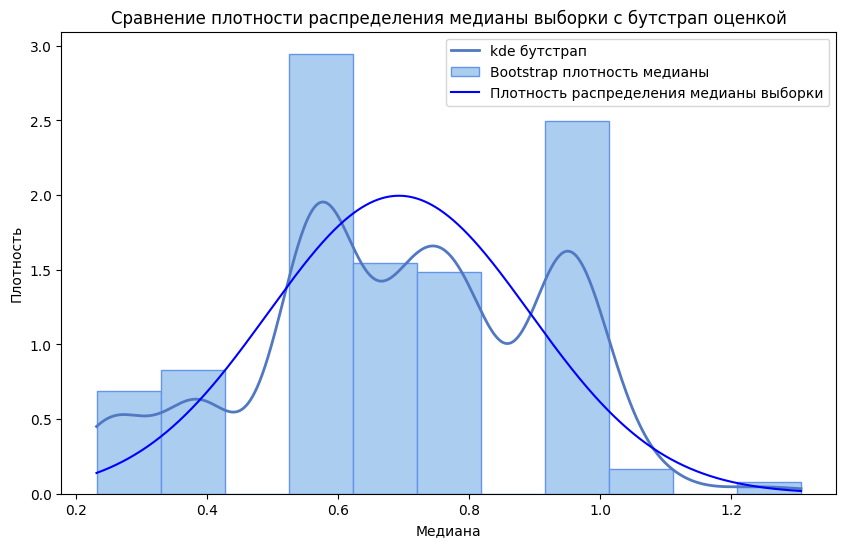

In [118]:
#Пункт e)

true_median = np.log(2)
ro_median = 0.5
etalon_std = 1 / (2 * np.sqrt(len(sample)) * ro_median)

bootstrap_medians = np.array([np.median(i) for i in bsp_samples])
bsp_std = np.std(bootstrap_medians)

print(f"Разница среднеквадратичных отклонений: {etalon_std-bsp_std}")

X = np.linspace(np.min(bootstrap_medians), np.max(bootstrap_medians), 1000)
Y = stats.norm.pdf(X, true_median, etalon_std)

plt.figure(figsize=(10, 6))
kde = stats.gaussian_kde(bootstrap_medians)
x = np.linspace(np.min(bootstrap_medians), np.max(bootstrap_medians), 1000)
y_kde = kde(x)
plt.plot(x, y_kde, linewidth=2, label='kde бутстрап', color="#5178C2FF")
plt.hist(bootstrap_medians, 1 + int(np.round(np.log2(1000))), density=True, edgecolor="#6495ED", facecolor="#ABCDEF", label="Bootstrap плотность медианы")
plt.plot(X, Y, c="blue", label="Плотность распределения медианы выборки")
plt.ylabel("Плотность")
plt.xlabel("Медиана")
plt.title("Сравнение плотности распределения медианы выборки с бутстрап оценкой")
plt.legend(loc="upper right")
plt.show()
